100%|██████████| 26.4M/26.4M [00:01<00:00, 21.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 339kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.28MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.4MB/s]


Epoch 1 finished
Train Loss: 0.7057 | Train Acc: 74.58%
Val Loss: 0.5047 | Val Acc: 81.39%
------------------------------
Epoch 2 finished
Train Loss: 0.4643 | Train Acc: 83.32%
Val Loss: 0.4494 | Val Acc: 83.94%
------------------------------
Epoch 3 finished
Train Loss: 0.4245 | Train Acc: 84.86%
Val Loss: 0.4244 | Val Acc: 84.81%
------------------------------
Epoch 4 finished
Train Loss: 0.4017 | Train Acc: 85.64%
Val Loss: 0.4295 | Val Acc: 84.07%
------------------------------
Epoch 5 finished
Train Loss: 0.3876 | Train Acc: 86.19%
Val Loss: 0.4372 | Val Acc: 84.57%
------------------------------
Epoch 6 finished
Train Loss: 0.3773 | Train Acc: 86.45%
Val Loss: 0.4056 | Val Acc: 85.09%
------------------------------
Epoch 7 finished
Train Loss: 0.3654 | Train Acc: 86.96%
Val Loss: 0.3888 | Val Acc: 85.84%
------------------------------
Epoch 8 finished
Train Loss: 0.3578 | Train Acc: 87.15%
Val Loss: 0.4065 | Val Acc: 85.01%
------------------------------
Epoch 9 finished
Train L

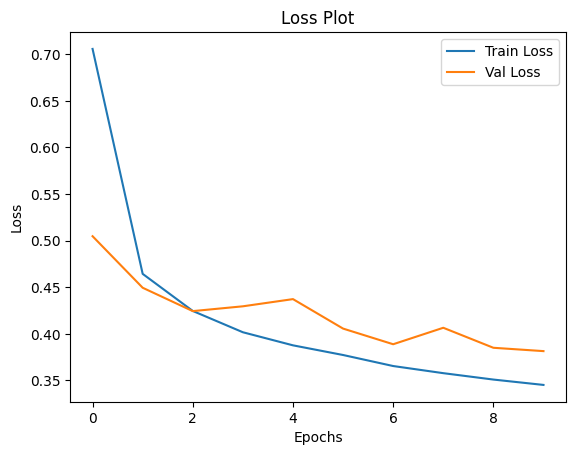

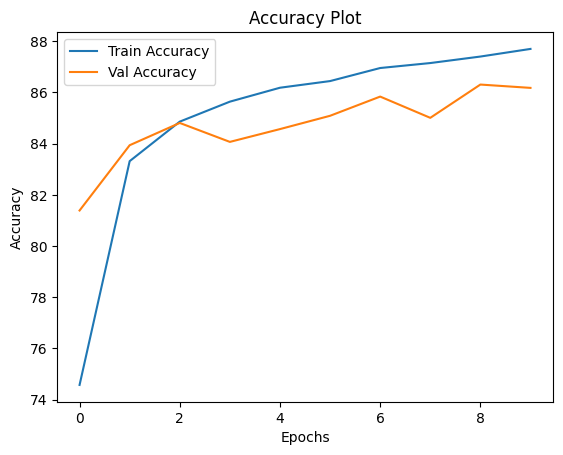

Saved model weights sucessfully
Saved submission.csv sucessfully


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

class MyNeuralNetwork(nn.Module):
    def __init__(self):
        super(MyNeuralNetwork, self).__init__()

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 16)
        self.relu = nn.ReLU()

        self.l1 = nn.Linear(16, 8)
        self.l2 = nn.Linear(8, 8)

        self.r1 = nn.Linear(16, 12)
        self.r2 = nn.Linear(12, 8)

        self.out = nn.Linear(16, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))

        a = self.relu(self.l1(x))
        b = self.relu(self.l2(a))
        left = a + b

        c = self.relu(self.r1(x))
        right = self.relu(self.r2(c))

        x = torch.cat((left, right), dim=1)

        x = self.out(x)
        return x

t = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set_full = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=t
)

test_set = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=t
)

train_set, val_set = torch.utils.data.random_split(
    train_set_full,
    [50000, 10000]
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=64,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=64,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=64,
    shuffle=False
)

model = MyNeuralNetwork()

loss_fn = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=0.001)

tr_loss = []
tr_acc = []

v_loss = []
v_acc = []

epochs = 10

for ep in range(epochs):

    model.train()

    t_loss = 0
    c = 0
    n = 0

    for imgs, labs in train_loader:

        opt.zero_grad()

        out = model(imgs)

        loss = loss_fn(out, labs)

        loss.backward()
        opt.step()

        t_loss += loss.item() * imgs.size(0)

        _, pred = torch.max(out, 1)

        n += labs.size(0)
        c += (pred == labs).sum().item()

    e_train_loss = t_loss / n
    e_train_acc = (c / n) * 100

    tr_loss.append(e_train_loss)
    tr_acc.append(e_train_acc)

    model.eval()

    t_v_loss = 0
    c_v = 0
    n_v = 0

    with torch.no_grad():

        for imgs, labs in val_loader:

            out = model(imgs)

            loss = loss_fn(out, labs)

            t_v_loss += loss.item() * imgs.size(0)

            _, pred = torch.max(out, 1)

            n_v += labs.size(0)
            c_v += (pred == labs).sum().item()

    e_val_loss = t_v_loss / n_v
    e_val_acc = (c_v / n_v) * 100

    v_loss.append(e_val_loss)
    v_acc.append(e_val_acc)

    print("Epoch " + str(ep + 1) + " finished")
    print("Train Loss: " + str(round(e_train_loss, 4)) + " | Train Acc: " + str(round(e_train_acc, 2)) + "%")
    print("Val Loss: " + str(round(e_val_loss, 4)) + " | Val Acc: " + str(round(e_val_acc, 2)) + "%")
    print("-" * 30)

plt.figure()
plt.plot(tr_loss, label='Train Loss')
plt.plot(v_loss, label='Val Loss')
plt.title('Loss Plot')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('loss_plot.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.plot(tr_acc, label='Train Accuracy')
plt.plot(v_acc, label='Val Accuracy')
plt.title('Accuracy Plot')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('accuracy_plot.png', dpi=300, bbox_inches='tight')
plt.show()

w = model.state_dict()

f = open('model_weights.pkl', 'wb')
pickle.dump(w, f)
f.close()

print("Saved model weights sucessfully")

model.eval()

preds = []

with torch.no_grad():

    for imgs, _ in test_loader:

        out = model(imgs)

        _, pred = torch.max(out, 1)

        for x in pred.numpy():
            preds.append(x)

sub = {
    'Id': list(range(len(preds))),
    'Label': preds
}

df = pd.DataFrame(sub)

df.to_csv('submission.csv', index=False)

print("Saved submission.csv sucessfully")